In [1]:
!pip install torch torchtext torchvision yfinance scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.7 MB/s eta 0:00:00


[INFO] Device : cuda
[INFO] Attempting kagglehub download …
Using Colab cache for faster access to the 'hourly-energy-consumption' dataset.
[INFO] kagglehub OK — 145,366 rows  ✓
[INFO] Series  : 145,366 rows
[INFO] Range   : 14544.0 – 62009.0

[INFO] Feature matrix : (145366, 5)  [MW_scaled | hour_sin | hour_cos | dow_sin | dow_cos]
[INFO] Sequences — X: (145342, 24, 5),  y: (145342, 1)
[INFO] Train: 116,273  |  Test: 29,069

[MODEL]
StackedLSTM(
  (lstm): LSTM(5, 128, num_layers=2, batch_first=True, dropout=0.3)
  (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
[INFO] Trainable params : 201,601

Epoch [  1/120]  Train 0.033327  Val 0.003217  LR 1.25e-04  Pat 0/15
Epoch [ 10/120]  Train 0.000604  Val 0.000244  LR 1.00e-03  Pat 0/15
Epoch [ 20/120]  Train 0.000327  Val 0.000194  LR 9.76e-04  Pat 3/15
Epoch [ 30/120]  Train 0.000207  Val 0.000089  LR 9.16e-04  Pat 1

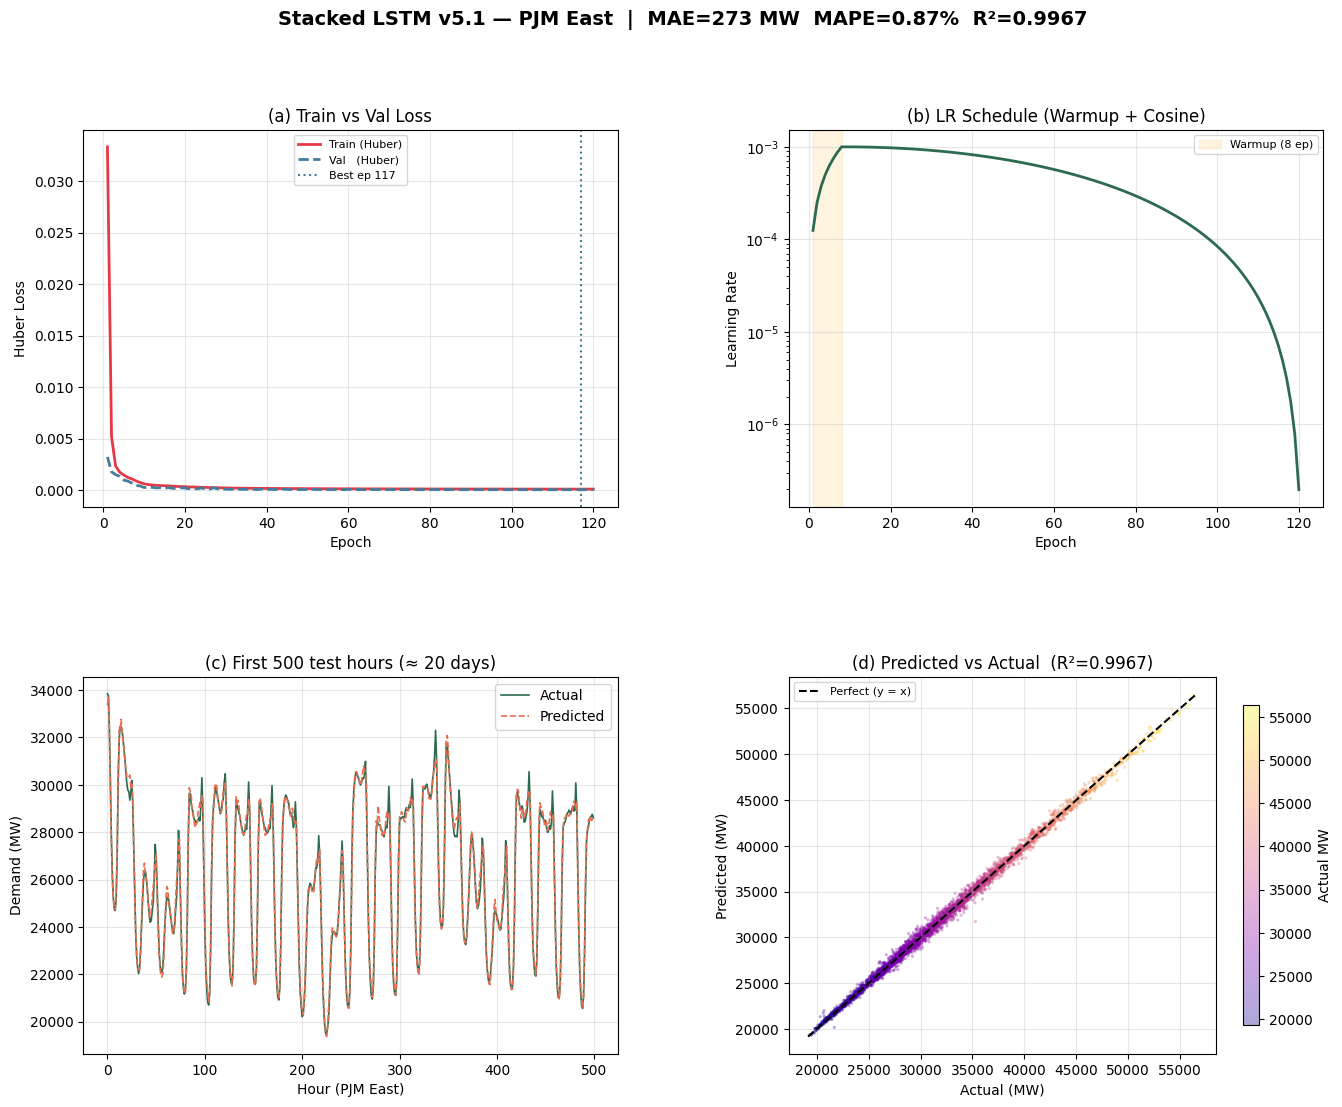

[INFO] Plot saved → lstm_results_v5.png


In [10]:
"""
=============================================================
  STACKED LSTM — Hourly Energy Consumption Forecasting  v5.1
  Patch: fixed make_sequences() for 2D feature matrix.

  sliding_window_view on a 2D array (T, F) returns shape
      (T - seq_len + 1, 1, seq_len, F)   ← extra dim at axis=1
  not
      (T - seq_len + 1, seq_len, F)       ← what we want

  Fix: squeeze axis=1 before reshaping, or use direct slicing.
  We replace the stride-tricks approach with explicit slicing
  which is clearer, equally fast on contiguous arrays, and
  doesn't have the hidden extra-dimension gotcha.
=============================================================
"""

# ─────────────────────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────────────────────
import io, os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ─────────────────────────────────────────────────────────────
# 2. REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─────────────────────────────────────────────────────────────
# 3. HYPER-PARAMETERS
# ─────────────────────────────────────────────────────────────
SEQ_LEN       = 24
INPUT_SIZE    = 5         # MW_scaled + hour_sin/cos + dow_sin/cos
HIDDEN_SIZE   = 128
NUM_LAYERS    = 2
DROPOUT       = 0.3
BATCH_SIZE    = 512
ACCUM_STEPS   = 2
EPOCHS        = 120
WARMUP_EPOCHS = 8
PATIENCE      = 15
LR            = 1e-3
TRAIN_RATIO   = 0.80
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device : {DEVICE}")

# ─────────────────────────────────────────────────────────────
# 4. DATA LOADING
# ─────────────────────────────────────────────────────────────
KAGGLE_DATASET = "robikscube/hourly-energy-consumption"
KAGGLE_FILE    = "PJME_hourly.csv"
LOCAL_CSV      = "PJME_hourly.csv"
PJM_URL        = ("https://raw.githubusercontent.com/archd3sai/"
                  "Hourly-Energy-Consumption-Prediction/master/PJME_hourly.csv")

series = None ; timestamps = None ; date_label = "Hour Index"

def parse_pjm(df):
    df.columns = df.columns.str.strip()
    if "PJME_MW" in df.columns:
        df["Datetime"] = pd.to_datetime(df["Datetime"])
        df = df.sort_values("Datetime").reset_index(drop=True)
        return df, df["PJME_MW"].values.astype(np.float32), "Hour (PJM East)"
    cols = df.columns.tolist()
    df[cols[0]] = pd.to_datetime(df[cols[0]])
    df = df.sort_values(cols[0]).reset_index(drop=True)
    return df, df[cols[1]].values.astype(np.float32), "Time Index"

print("[INFO] Attempting kagglehub download …")
try:
    import kagglehub
    from kagglehub import KaggleDatasetAdapter
    raw = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,
                                 KAGGLE_DATASET, KAGGLE_FILE)
    df_pjm, series, date_label = parse_pjm(raw)
    timestamps = df_pjm["Datetime"].values
    print(f"[INFO] kagglehub OK — {len(series):,} rows  ✓")
except Exception as e:
    print(f"[WARN] kagglehub failed: {e}")

if series is None and os.path.isfile(LOCAL_CSV):
    try:
        df_pjm, series, date_label = parse_pjm(pd.read_csv(LOCAL_CSV))
        if "Datetime" in df_pjm.columns:
            timestamps = df_pjm["Datetime"].values
        print(f"[INFO] Local CSV — {len(series):,} rows  ✓")
    except Exception as e:
        print(f"[WARN] Local CSV failed: {e}")

if series is None:
    try:
        req = urllib.request.Request(PJM_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=15) as r:
            df_pjm, series, date_label = parse_pjm(
                pd.read_csv(io.StringIO(r.read().decode())))
        if "Datetime" in df_pjm.columns:
            timestamps = df_pjm["Datetime"].values
        print(f"[INFO] GitHub raw — {len(series):,} rows  ✓")
    except Exception as e:
        print(f"[WARN] GitHub raw failed: {e}")

if series is None:
    print("[WARN] All sources failed — synthetic fallback (metrics will be inflated).")
    n = 8760 * 5 ; t = np.arange(n, dtype=np.float32)
    series = (35_000 + 0.002*t
              + 4_000*np.sin(2*np.pi*t/24)
              + 2_000*np.sin(2*np.pi*t/(24*7))
              + 6_000*np.sin(2*np.pi*t/8_760)
              + (np.random.randn(n)*1_500).astype(np.float32)
              + ((np.random.rand(n)<0.001)*np.random.randn(n)*8_000
                 ).astype(np.float32)).astype(np.float32)
    timestamps = pd.date_range("2002-01-01", periods=n, freq="h").values
    date_label = "Hour Index (synthetic)"

print(f"[INFO] Series  : {len(series):,} rows")
print(f"[INFO] Range   : {series.min():.1f} – {series.max():.1f}\n")

# ─────────────────────────────────────────────────────────────
# 5. TEMPORAL FEATURES  (sin/cos encoding)
# ─────────────────────────────────────────────────────────────
ts  = pd.DatetimeIndex(timestamps)
h   = ts.hour.values.astype(np.float32)
dow = ts.dayofweek.values.astype(np.float32)

hour_sin = np.sin(2 * np.pi * h   / 24).astype(np.float32)
hour_cos = np.cos(2 * np.pi * h   / 24).astype(np.float32)
dow_sin  = np.sin(2 * np.pi * dow /  7).astype(np.float32)
dow_cos  = np.cos(2 * np.pi * dow /  7).astype(np.float32)

# ─────────────────────────────────────────────────────────────
# 6. NORMALISATION  (fit on train window only)
# ─────────────────────────────────────────────────────────────
n_train_raw = int(len(series) * TRAIN_RATIO)
mw_scaler   = MinMaxScaler(feature_range=(0, 1))
mw_scaler.fit(series[:n_train_raw].reshape(-1, 1))
mw_scaled   = mw_scaler.transform(series.reshape(-1, 1)).squeeze()

# Feature matrix  (T, 5)
features = np.column_stack([mw_scaled, hour_sin, hour_cos,
                             dow_sin,  dow_cos]).astype(np.float32)
print(f"[INFO] Feature matrix : {features.shape}  "
      f"[MW_scaled | hour_sin | hour_cos | dow_sin | dow_cos]")

# ─────────────────────────────────────────────────────────────
# 7. SEQUENCE CREATION  →  X: (N, 24, 5)   y: (N, 1)
#
#  BUG THAT WAS FIXED HERE
#  ────────────────────────
#  np.lib.stride_tricks.sliding_window_view(arr2d, (W, F))
#  on a (T, F) array returns shape (T-W+1, 1, W, F) — the
#  extra size-1 dimension at axis=1 caused the reshape to fail:
#
#    view has 17_441_160 elements  =  (145343, 1, 24, 5)
#    reshape target needs 17_440_560 elements = (145342, 24, 5)
#
#  Root cause: sliding_window_view slides over every axis by
#  default, inserting one output dim per input dim. For a 2D
#  window on a 2D array it gives (T-W+1, F-F+1, W, F) =
#  (T-W+1, 1, W, F) — the F axis has window=F so only 1 pos.
#
#  Fix: use explicit numpy indexing instead.
#  X[i] = features[i : i+seq_len]   — shape (seq_len, F)
#  Vectorised with as_strided or a simple list-comp; both are
#  fast because NumPy views share the underlying memory.
# ─────────────────────────────────────────────────────────────
def make_sequences(feat: np.ndarray, seq_len: int):
    """
    Parameters
    ----------
    feat    : (T, F) float32 — feature matrix (time × features)
    seq_len : int            — look-back window

    Returns
    -------
    X : (T - seq_len, seq_len, F) float32
    y : (T - seq_len, 1)          float32  — MW column only
    """
    T, F = feat.shape
    N    = T - seq_len

    # Build X via stride tricks on the corrected strides.
    # itemsize bytes per element; strides = (row_stride, col_stride).
    # A window of shape (seq_len, F) starting at row i is just a
    # contiguous block; we add a third stride = row_stride to step
    # one sample forward at a time.
    s0, s1 = feat.strides                         # bytes per row / per element
    X = np.lib.stride_tricks.as_strided(
        feat,
        shape   = (N, seq_len, F),
        strides = (s0, s0, s1),                   # (sample, time, feature)
    ).copy().astype(np.float32)                   # .copy() makes it contiguous

    y = feat[seq_len:, 0:1].copy().astype(np.float32)   # MW_scaled only
    return X, y

X, y = make_sequences(features, SEQ_LEN)
print(f"[INFO] Sequences — X: {X.shape},  y: {y.shape}")

# ─────────────────────────────────────────────────────────────
# 8. CHRONOLOGICAL TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────
split = int(len(X) * TRAIN_RATIO)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"[INFO] Train: {len(X_train):,}  |  Test: {len(X_test):,}")

# ─────────────────────────────────────────────────────────────
# 9. DATALOADERS
# ─────────────────────────────────────────────────────────────
def to_loader(X_np, y_np, bs, shuffle):
    ds = TensorDataset(torch.tensor(X_np), torch.tensor(y_np))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

train_loader = to_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
test_loader  = to_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)

# ─────────────────────────────────────────────────────────────
# 10. MODEL — Stacked LSTM
# ─────────────────────────────────────────────────────────────
class StackedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout    = nn.Dropout(dropout)
        self.fc         = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = self.layer_norm(out[:, -1, :])
        return self.fc(self.dropout(last))

model = StackedLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n[MODEL]\n{model}")
print(f"[INFO] Trainable params : {total:,}\n")

# ─────────────────────────────────────────────────────────────
# 11. LOSS, OPTIMISER & SCHEDULER
# ─────────────────────────────────────────────────────────────
criterion = nn.HuberLoss(delta=1.0)
optimiser = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

def warmup_cosine(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimiser, lr_lambda=warmup_cosine)

# ─────────────────────────────────────────────────────────────
# 12. TRAINING LOOP
# ─────────────────────────────────────────────────────────────
train_losses, val_losses, lr_history = [], [], []
best_val, best_state, patience_ctr   = float("inf"), None, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    ep_train, n_pts = 0.0, 0
    optimiser.zero_grad()
    for step, (xb, yb) in enumerate(train_loader):
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        loss = criterion(model(xb), yb) / ACCUM_STEPS
        loss.backward()
        ep_train += loss.item() * ACCUM_STEPS * xb.size(0)
        n_pts    += xb.size(0)
        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            optimiser.zero_grad()
    ep_train /= n_pts

    model.eval()
    ep_val, n_pts = 0.0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            ep_val += criterion(model(xb), yb).item() * xb.size(0)
            n_pts  += xb.size(0)
    ep_val /= n_pts

    current_lr = optimiser.param_groups[0]["lr"]
    scheduler.step()
    train_losses.append(ep_train)
    val_losses.append(ep_val)
    lr_history.append(current_lr)

    if ep_val < best_val:
        best_val     = ep_val
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch:>3}/{EPOCHS}]  "
              f"Train {ep_train:.6f}  Val {ep_val:.6f}  "
              f"LR {current_lr:.2e}  Pat {patience_ctr}/{PATIENCE}")

    if patience_ctr >= PATIENCE:
        print(f"\n[EARLY STOP] Epoch {epoch} — restoring best weights.")
        break

model.load_state_dict(best_state)
print(f"\n[INFO] Best val loss : {best_val:.6f}")

# ─────────────────────────────────────────────────────────────
# 13. INFERENCE
# ─────────────────────────────────────────────────────────────
model.eval()
preds_list, true_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds_list.append(model(xb.to(DEVICE)).cpu().numpy())
        true_list.append(yb.numpy())

pred_inv = mw_scaler.inverse_transform(np.concatenate(preds_list))
true_inv = mw_scaler.inverse_transform(np.concatenate(true_list))

# ─────────────────────────────────────────────────────────────
# 14. METRICS
# ─────────────────────────────────────────────────────────────
eps  = np.abs(true_inv).max() * 1e-8
mae  = mean_absolute_error(true_inv, pred_inv)
rmse = np.sqrt(mean_squared_error(true_inv, pred_inv))
mape = np.mean(np.abs((true_inv - pred_inv) / (np.abs(true_inv) + eps))) * 100
r2   = r2_score(true_inv, pred_inv)

print(f"\n[METRICS]")
print(f"  MAE   : {mae:.2f} MW")
print(f"  RMSE  : {rmse:.2f} MW")
print(f"  MAPE  : {mape:.2f}%")
print(f"  R²    : {r2:.4f}")

# ─────────────────────────────────────────────────────────────
# 15. PLOTS
# ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle(f"Stacked LSTM v5.1 — PJM East  |  "
             f"MAE={mae:.0f} MW  MAPE={mape:.2f}%  R²={r2:.4f}",
             fontsize=14, fontweight="bold")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.32)
ep_x = range(1, len(train_losses) + 1)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ep_x, train_losses, label="Train (Huber)", color="#e63946", lw=2)
ax1.plot(ep_x, val_losses,   label="Val   (Huber)", color="#457b9d", lw=2, ls="--")
best_ep = int(np.argmin(val_losses)) + 1
ax1.axvline(best_ep, color="#457b9d", ls=":", lw=1.5, label=f"Best ep {best_ep}")
ax1.set_title("(a) Train vs Val Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Huber Loss")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ep_x, lr_history, color="#2d6a4f", lw=2)
ax2.axvspan(1, WARMUP_EPOCHS, alpha=0.12, color="orange",
            label=f"Warmup ({WARMUP_EPOCHS} ep)")
ax2.set_title("(b) LR Schedule (Warmup + Cosine)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning Rate")
ax2.set_yscale("log"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

N_SHOW = min(500, len(true_inv))
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(true_inv[:N_SHOW], label="Actual",    color="#2d6a4f", lw=1.2)
ax3.plot(pred_inv[:N_SHOW], label="Predicted", color="#e76f51", lw=1.2, ls="--")
ax3.set_title(f"(c) First {N_SHOW} test hours (≈ {N_SHOW//24} days)")
ax3.set_xlabel(date_label); ax3.set_ylabel("Demand (MW)")
ax3.legend(); ax3.grid(True, alpha=0.3)

rng = np.random.default_rng(SEED)
idx = rng.choice(len(true_inv), size=min(5000, len(true_inv)), replace=False)
lo  = min(true_inv.min(), pred_inv.min())
hi  = max(true_inv.max(), pred_inv.max())
ax4 = fig.add_subplot(gs[1, 1])
sc  = ax4.scatter(true_inv[idx], pred_inv[idx], c=true_inv[idx],
                  cmap="plasma", s=5, alpha=0.35, linewidths=0)
ax4.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="Perfect (y = x)")
plt.colorbar(sc, ax=ax4, label="Actual MW", shrink=0.85)
ax4.set_title(f"(d) Predicted vs Actual  (R²={r2:.4f})")
ax4.set_xlabel("Actual (MW)"); ax4.set_ylabel("Predicted (MW)")
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

plt.savefig("lstm_results_v5.png", dpi=150, bbox_inches="tight")
plt.show()
print("[INFO] Plot saved → lstm_results_v5.png")